In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("/Users/anandadide/Documents/GitHub/VesselAttributesPrediction")
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

import math

import matplotlib.pyplot as plt
import numpy as np
from vesselattributeprediction.model.vesselAttributeModel import VesselAttributeModel

/Users/anandadide/Documents/GitHub/VesselAttributesPrediction/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Initialize vessel model
model_file = "detector_model_training/vessel_detector_model.keras"
vessel_attribute_predictor = VesselAttributeModel(model_file)

In [7]:
# Predict on one test image
root_data_dir = PROJECT_ROOT / "data" / "train_images"
image_file = "764.tif"
prediction_results = vessel_attribute_predictor.detect_vessel_attributes(root_data_dir / image_file)

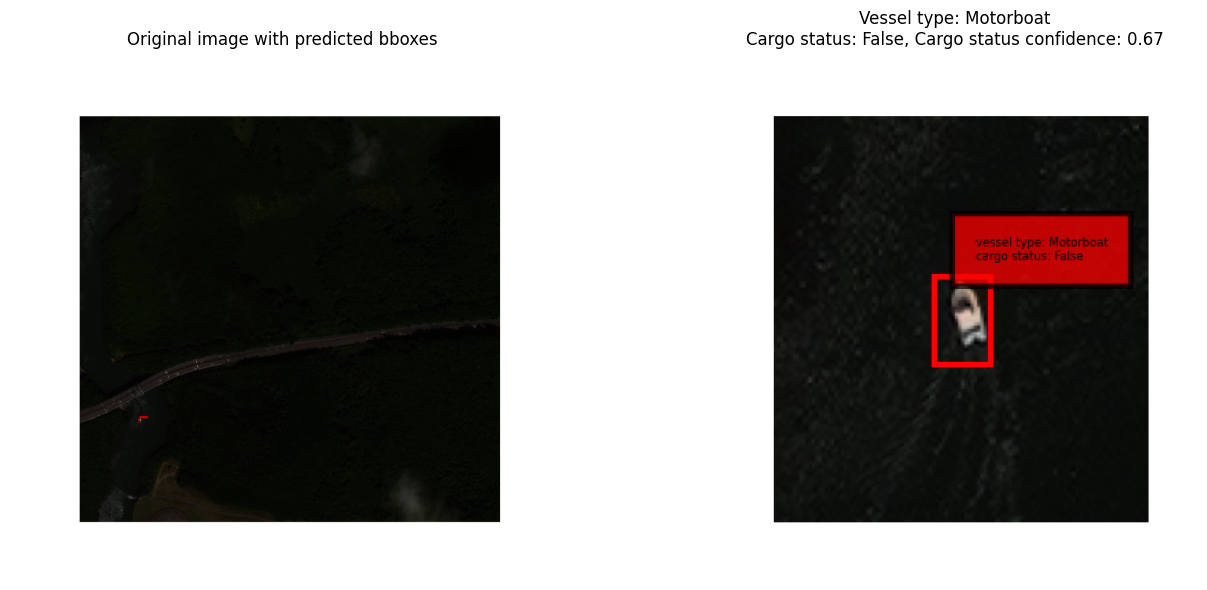

In [8]:
# Visualize detected vessels
if prediction_results["num_vessels_detected"] is None:
    raise ValueError("No vessel objects detected.")

vessels = prediction_results["vessels"]
num_plots = len(vessels) + 1

num_cols = min(2, num_plots)
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(
    num_rows,
    num_cols,
    figsize=(7 * num_cols, 6 * num_rows),
)
axes = np.asarray(axes).reshape(-1)

axes[0].imshow(prediction_results["annotated_image"])
axes[0].set_title("Original image with predicted bboxes")
axes[0].axis("off")

for ax, vessel_result in zip(axes[1:], vessels):
    ax.imshow(vessel_result["annotated_vessel_crop"])
    ax.set_title(
        f"Vessel type: {vessel_result['vessel_type']}\n"
        f"Cargo status: {vessel_result['cargo_status']}, "
        f"Cargo status confidence: {vessel_result['cargo_confidence']:.2f}"
    )
    ax.axis("off")

for ax in axes[num_plots:]:
    ax.axis("off")

plt.tight_layout()
plt.show()